### As we generated this synthetic dataset ourselves, we have a unique advantage: we actually know the hidden ground truth (the original archetypes). This allows us to use highly accurate external evaluation metrics to see if the K-Means algorithm actually found the exact playstyles we embedded in the data.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

In [5]:
# Load the data, separate features from the hidden labels, and run the predictions
df_scaled = pd.read_csv('../data/valorant_scaled_data.csv')
df_original = pd.read_csv('../data/valorant_synthetic_data_raw.csv')
X = df_scaled.drop(columns=['player_id', 'archetype'])
true_labels = df_original['archetype']
predicted_labels = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)

In [6]:
# Calculate the Silhouette Score to measure the internal density and separation of the clusters
sil_score = silhouette_score(X, predicted_labels)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.2079


In [7]:
# Calculate ARI and NMI to see how closely the discovered clusters match our hidden ground truth
ari_score = adjusted_rand_score(true_labels, predicted_labels)
nmi_score = normalized_mutual_info_score(true_labels, predicted_labels)
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi_score:.4f}")

Adjusted Rand Index (ARI): 0.8935
Normalized Mutual Info (NMI): 0.8725


In [8]:
# Create a matrix showing exactly how many players from each true archetype ended up in each discovered cluster
mapping_matrix = pd.crosstab(true_labels, predicted_labels, rownames=['True Archetype'], colnames=['Discovered Cluster'])
display(mapping_matrix)

Discovered Cluster,0,1,2,3,4
True Archetype,,,,,
Aggressive Entry,0,10,990,0,0
Balanced Flex,14,946,3,17,20
Lurker,979,19,1,1,0
Passive Support,1,21,0,935,43
Utility-Heavy,0,14,0,59,927


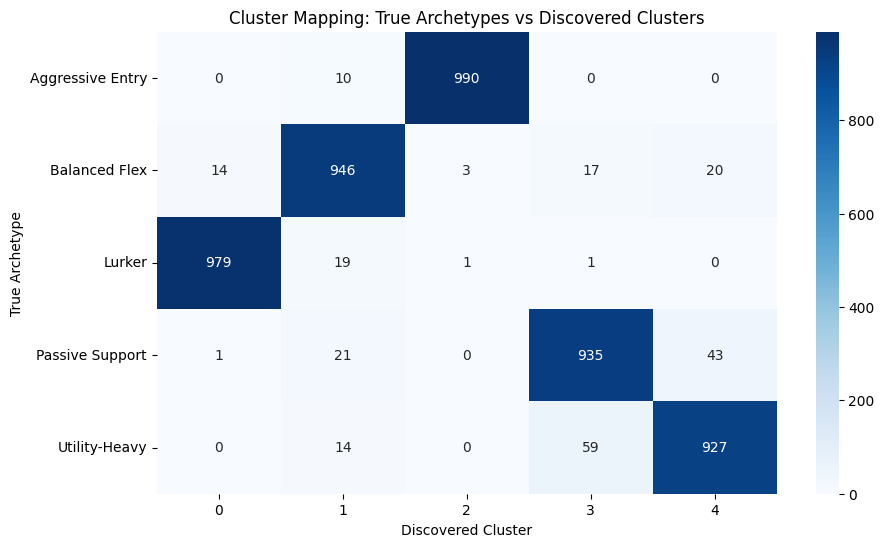

In [11]:
# Plot this mapping as a heatmap and save it to our viz folder
plt.figure(figsize=(10, 6))
sns.heatmap(mapping_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Cluster Mapping: True Archetypes vs Discovered Clusters')
plt.show()
plt.savefig('../visualizations/cluster_evaluation_heatmap.png')
plt.close()

### Final Evaluation Analysis: What These Scores Mean

The combination of these specific scores tells a fascinating story about the reality of in-game Valorant statistics:

* **Silhouette Score (0.2079):** This score measures how dense and separated the clusters are (ranging from -1 to 1). A score of ~0.21 is relatively low, indicating that the edges of our clusters are "fuzzy" and overlapping. In the context of Valorant, this makes perfect sense. Player behaviors exist on a continuous spectrum. A "Balanced Flex" player will naturally have stats that occasionally bleed into the "Aggressive Entry" or "Passive Support" territories. [Image of overlapping clusters in K-means]
* **Adjusted Rand Index / ARI (0.8935):** This is an exceptional score. It measures the similarity between our hidden "true" archetypes and the model's blind predictions. An ARI of ~0.89 means that despite the overlapping stats, the algorithm successfully discovered the core behavioral patterns and matched players to their intended archetypes roughly 89% of the time.
* **Normalized Mutual Info / NMI (0.8725):** Similar to ARI, this excellent score confirms that the clusters the model grouped together contain almost all the information needed to correctly identify the true playstyles we injected. 
